In [1]:
import pandas as pd

In [2]:
df = pd.read_csv(r"C:\Users\niles\Downloads\SkyCity Auckland Restaurants & Bars.csv")

In [3]:
df.head()

,CuisineType,RestaurantID,RestaurantName,Segment,Subregion,GrowthFactor,AOV,MonthlyOrders,InStoreOrders,InStoreRevenue,...,DeliveryCostPerOrder,SD_DeliveryTotalCost,InStoreNetProfit,UberEatsNetProfit,DoorDashNetProfit,SelfDeliveryNetProfit,InStoreShare,UE_share,DD_share,SD_share
0,Burgers,25731,Urban Burgers House,Cafe,North Shore,1.03,43.97,668,197,8662.09,...,3.25,458.25,3682.14,1352.45,752.78,2177.19,0.42,0.45,0.25,0.3
1,Burgers,25123,Urban Burgers Diner,QSR,South Auckland,1.05,40.45,1388,259,10476.55,...,4.72,1600.08,3605.72,1318.61,731.99,3119.38,0.23,0.45,0.25,0.3
2,Burgers,25177,King Burgers Eatery,Cafe,West Auckland,1.04,40.03,1717,524,20975.72,...,3.25,1163.50,7810.95,1555.90,863.42,4172.99,0.44,0.45,0.25,0.3
3,Burgers,25540,Classic Burgers Tavern,QSR,North Shore,1.03,36.28,1083,216,7836.48,...,0.89,231.40,2546.02,-72.25,-40.20,2833.26,0.25,0.45,0.25,0.3
4,Burgers,25258,Lucky Burgers Bistro,Cafe,South Auckland,1.05,34.34,1230,261,8962.74,...,2.66,774.06,3093.09,226.17,125.53,2674.56,0.27,0.45,0.25,0.3


In [20]:
df.columns

Index(['CuisineType', 'RestaurantID', 'RestaurantName', 'Segment', 'Subregion',
       'GrowthFactor', 'AOV', 'MonthlyOrders', 'InStoreOrders',
       'InStoreRevenue', 'UberEatsOrders', 'DoorDashOrders',
       'SelfDeliveryOrders', 'UberEatsRevenue', 'DoorDashRevenue',
       'SelfDeliveryRevenue', 'COGSRate', 'OPEXRate', 'CommissionRate',
       'DeliveryRadiusKM', 'DeliveryCostPerOrder', 'SD_DeliveryTotalCost',
       'InStoreNetProfit', 'UberEatsNetProfit', 'DoorDashNetProfit',
       'SelfDeliveryNetProfit', 'InStoreShare', 'UE_share', 'DD_share',
       'SD_share', 'Calculated_InStore_Profit', 'Calculated_UE_Profit',
       'Calculated_DD_Profit', 'Calculated_SD_Profit', 'InStore_Profit_Diff',
       'UE_Profit_Diff', 'DD_Profit_Diff', 'SD_Profit_Diff', 'InStore_Valid',
       'UE_Valid', 'DD_Valid', 'SD_Valid'],
      dtype='object')

In [46]:
df.shape

(1696, 54)

In [42]:
# In-Store Validation
df['Calculated_InStore_Profit'] = (
    df['InStoreRevenue']
    - (df['COGSRate'] * df['InStoreRevenue'])
    - (df['OPEXRate'] * df['InStoreRevenue'])
)

# Uber Eats Validation
df['Calculated_UE_Profit'] = (
    df['UberEatsRevenue']
    - (df['COGSRate'] * df['UberEatsRevenue'])
    - (df['OPEXRate'] * df['UberEatsRevenue'])
    - (df['CommissionRate'] * df['UberEatsRevenue'])
)

# DoorDash Validation
df['Calculated_DD_Profit'] = (
    df['DoorDashRevenue']
    - (df['COGSRate'] * df['DoorDashRevenue'])
    - (df['OPEXRate'] * df['DoorDashRevenue'])
    - (df['CommissionRate'] * df['DoorDashRevenue'])
)

# Self Delivery Validation
df['Calculated_SD_Profit'] = (
    df['SelfDeliveryRevenue']
    - (df['COGSRate'] * df['SelfDeliveryRevenue'])
    - (df['OPEXRate'] * df['SelfDeliveryRevenue'])
    - df['SD_DeliveryTotalCost']
)

In [44]:
print(df[['RestaurantName',
          'Calculated_InStore_Profit',
          'Calculated_UE_Profit',
          'Calculated_DD_Profit',
          'Calculated_SD_Profit']].head())

           RestaurantName  Calculated_InStore_Profit  Calculated_UE_Profit  \
0     Urban Burgers House                3682.139757           1352.446529   
1     Urban Burgers Diner                3605.719378           1318.613792   
2     King Burgers Eatery                7810.945530           1555.895530   
3  Classic Burgers Tavern                2546.024526            -72.247272   
4    Lucky Burgers Bistro                3093.093274            226.167188   

   Calculated_DD_Profit  Calculated_SD_Profit  
0            752.776841           2177.190131  
1            731.986396           3119.375094  
2            863.420611           4172.985687  
3            -40.199123           2833.259152  
4            125.533164           2674.561236  


In [26]:
df['InStore_Diff'] = (
    df['InStoreNetProfit']
    - df['Calculated_InStore_Profit']
)

df['UE_Diff'] = (
    df['UberEatsNetProfit']
    - df['Calculated_UE_Profit']
)

df['DD_Diff'] = (
    df['DoorDashNetProfit']
    - df['Calculated_DD_Profit']
)

df['SD_Diff'] = (
    df['SelfDeliveryNetProfit']
    - df['Calculated_SD_Profit']
)

In [27]:
print(df[['RestaurantName',
          'InStore_Diff',
          'UE_Diff',
          'DD_Diff',
          'SD_Diff']].head())

           RestaurantName  InStore_Diff   UE_Diff   DD_Diff   SD_Diff
0     Urban Burgers House      0.000243  0.003471  0.003159 -0.000131
1     Urban Burgers Diner      0.000622 -0.003792  0.003604  0.004906
2     King Burgers Eatery      0.004470  0.004470 -0.000611  0.004313
3  Classic Burgers Tavern     -0.004526 -0.002728 -0.000877  0.000848
4    Lucky Burgers Bistro     -0.003274  0.002812 -0.003164 -0.001236


In [29]:
df['InStore_Profit_Per_Order'] = (
    df['InStoreNetProfit']
    / df['InStoreOrders']
)

df['UE_Profit_Per_Order'] = (
    df['UberEatsNetProfit']
    / df['UberEatsOrders']
)

df['DD_Profit_Per_Order'] = (
    df['DoorDashNetProfit']
    / df['DoorDashOrders']
)

df['SD_Profit_Per_Order'] = (
    df['SelfDeliveryNetProfit']
    / df['SelfDeliveryOrders']
)

In [30]:
print(df[['RestaurantName',
          'InStore_Profit_Per_Order',
          'UE_Profit_Per_Order',
          'DD_Profit_Per_Order',
          'SD_Profit_Per_Order']].head())

           RestaurantName  InStore_Profit_Per_Order  UE_Profit_Per_Order  \
0     Urban Burgers House                 18.691066             6.379481   
1     Urban Burgers Diner                 13.921699             2.595689   
2     King Burgers Eatery                 14.906393             2.897393   
3  Classic Burgers Tavern                 11.787130            -0.185256   
4    Lucky Burgers Bistro                 11.850920             0.518739   

   DD_Profit_Per_Order  SD_Profit_Per_Order  
0             6.379492            15.441064  
1             2.595709             9.201711  
2             2.897383            11.656397  
3            -0.185253            10.897154  
4             0.518719             9.190928  


In [31]:
df['InStore_Margin_Percent'] = (
    df['InStoreNetProfit']
    / df['InStoreRevenue']
) * 100

df['UE_Margin_Percent'] = (
    df['UberEatsNetProfit']
    / df['UberEatsRevenue']
) * 100

df['DD_Margin_Percent'] = (
    df['DoorDashNetProfit']
    / df['DoorDashRevenue']
) * 100

df['SD_Margin_Percent'] = (
    df['SelfDeliveryNetProfit']
    / df['SelfDeliveryRevenue']
) * 100

In [45]:
print(df[['RestaurantName',
          'InStore_Margin_Percent',
          'UE_Margin_Percent',
          'DD_Margin_Percent',
          'SD_Margin_Percent']].head())

           RestaurantName  InStore_Margin_Percent  UE_Margin_Percent  \
0     Urban Burgers House               42.508679          14.508713   
1     Urban Burgers Diner               34.417055           6.417031   
2     King Burgers Eatery               37.238054           7.238054   
3  Classic Burgers Tavern               32.489332          -0.510630   
4    Lucky Burgers Bistro               34.510540           1.510596   

   DD_Margin_Percent  SD_Margin_Percent  
0          14.508737          35.117270  
1           6.417081          22.748358  
2           7.238028          29.119152  
3          -0.510621          30.036256  
4           1.510539          26.764496  


In [32]:
Q1 = df['UE_Margin_Percent'].quantile(0.25)
Q3 = df['UE_Margin_Percent'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

ue_outliers = df[
    (df['UE_Margin_Percent'] < lower_bound) |
    (df['UE_Margin_Percent'] > upper_bound)
]

In [33]:
print(ue_outliers[['RestaurantName',
                   'UE_Margin_Percent']])

Empty DataFrame
Columns: [RestaurantName, UE_Margin_Percent]
Index: []


In [35]:
Q1 = df['InStore_Margin_Percent'].quantile(0.25)
Q3 = df['InStore_Margin_Percent'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

instore_outliers = df[
    (df['InStore_Margin_Percent'] < lower_bound) |
    (df['InStore_Margin_Percent'] > upper_bound)
]

In [38]:
print(instore_outliers[['RestaurantName',
                   'InStore_Margin_Percent']])

Empty DataFrame
Columns: [RestaurantName, InStore_Margin_Percent]
Index: []


In [36]:
Q1 = df['DD_Margin_Percent'].quantile(0.25)
Q3 = df['DD_Margin_Percent'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

dd_outliers = df[
    (df['DD_Margin_Percent'] < lower_bound) |
    (df['DD_Margin_Percent'] > upper_bound)
]

In [39]:
print(dd_outliers[['RestaurantName',
                   'DD_Margin_Percent']])

Empty DataFrame
Columns: [RestaurantName, DD_Margin_Percent]
Index: []


In [37]:
Q1 = df['SD_Margin_Percent'].quantile(0.25)
Q3 = df['SD_Margin_Percent'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

sd_outliers = df[
    (df['SD_Margin_Percent'] < lower_bound) |
    (df['SD_Margin_Percent'] > upper_bound)
]

In [40]:
print(sd_outliers[['RestaurantName',
                   'SD_Margin_Percent']])

Empty DataFrame
Columns: [RestaurantName, SD_Margin_Percent]
Index: []


In [47]:
channel_profit = {
    'InStore': df['InStoreNetProfit'].sum(),
    'UberEats': df['UberEatsNetProfit'].sum(),
    'DoorDash': df['DoorDashNetProfit'].sum(),
    'SelfDelivery': df['SelfDeliveryNetProfit'].sum()
}

print(channel_profit)

{'InStore': np.float64(3828417.36), 'UberEats': np.float64(258488.08000000002), 'DoorDash': np.float64(151122.25), 'SelfDelivery': np.float64(3628278.4400000004)}


In [48]:
avg_channel_profit = {
    'InStore': df['InStoreNetProfit'].mean(),
    'UberEats': df['UberEatsNetProfit'].mean(),
    'DoorDash': df['DoorDashNetProfit'].mean(),
    'SelfDelivery': df['SelfDeliveryNetProfit'].mean()
}

print(avg_channel_profit)

{'InStore': np.float64(2257.3215566037734), 'UberEats': np.float64(152.4104245283019), 'DoorDash': np.float64(89.10510023584905), 'SelfDelivery': np.float64(2139.3151179245287)}


In [49]:
avg_margin = {
    'InStore': df['InStore_Margin_Percent'].mean(),
    'UberEats': df['UE_Margin_Percent'].mean(),
    'DoorDash': df['DD_Margin_Percent'].mean(),
    'SelfDelivery': df['SD_Margin_Percent'].mean()
}

print(avg_margin)

{'InStore': np.float64(30.8201182933269), 'UberEats': np.float64(0.7924059344049814), 'DoorDash': np.float64(0.7924077927333661), 'SelfDelivery': np.float64(22.597175249691666)}


In [50]:
import pandas as pd

comparison_df = pd.DataFrame({
    'Channel': ['InStore', 'UberEats', 'DoorDash', 'SelfDelivery'],
    
    'Total_Net_Profit': [
        df['InStoreNetProfit'].sum(),
        df['UberEatsNetProfit'].sum(),
        df['DoorDashNetProfit'].sum(),
        df['SelfDeliveryNetProfit'].sum()
    ],
    
    'Average_Margin_Percent': [
        df['InStore_Margin_Percent'].mean(),
        df['UE_Margin_Percent'].mean(),
        df['DD_Margin_Percent'].mean(),
        df['SD_Margin_Percent'].mean()
    ],
    
    'Profit_Per_Order': [
        df['InStore_Profit_Per_Order'].mean(),
        df['UE_Profit_Per_Order'].mean(),
        df['DD_Profit_Per_Order'].mean(),
        df['SD_Profit_Per_Order'].mean()
    ]
})

print(comparison_df)

        Channel  Total_Net_Profit  Average_Margin_Percent  Profit_Per_Order
0       InStore        3828417.36               30.820118         11.901925
1      UberEats         258488.08                0.792406          0.340201
2      DoorDash         151122.25                0.792408          0.340202
3  SelfDelivery        3628278.44               22.597175          8.782562


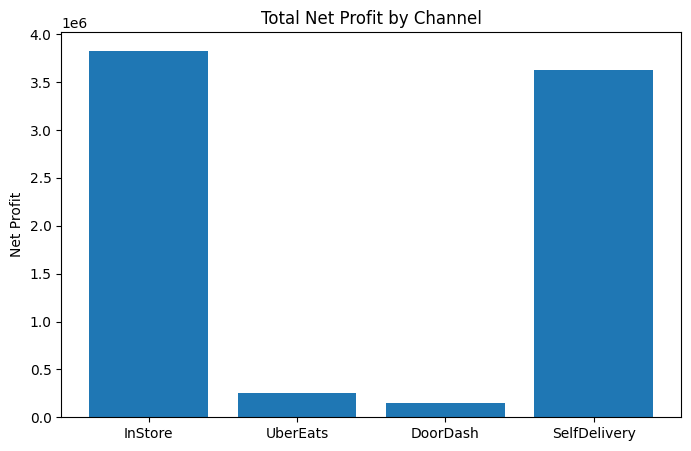

In [51]:
import matplotlib.pyplot as plt

profits = comparison_df['Total_Net_Profit']
channels = comparison_df['Channel']

plt.figure(figsize=(8,5))

plt.bar(channels, profits)

plt.title('Total Net Profit by Channel')
plt.ylabel('Net Profit')

plt.show()

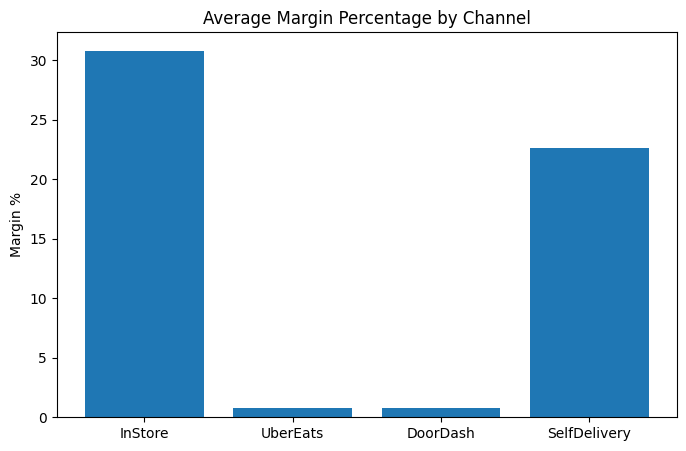

In [52]:
margins = comparison_df['Average_Margin_Percent']

plt.figure(figsize=(8,5))

plt.bar(channels, margins)

plt.title('Average Margin Percentage by Channel')
plt.ylabel('Margin %')

plt.show()

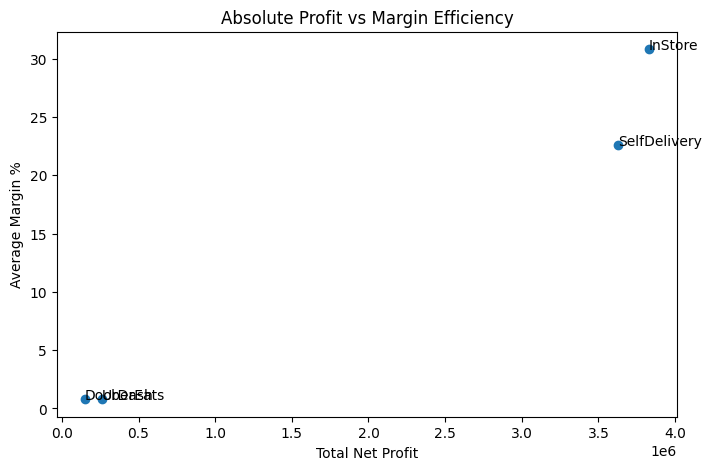

In [53]:
plt.figure(figsize=(8,5))

plt.scatter(
    comparison_df['Total_Net_Profit'],
    comparison_df['Average_Margin_Percent']
)

for i, channel in enumerate(comparison_df['Channel']):
    plt.text(
        comparison_df['Total_Net_Profit'][i],
        comparison_df['Average_Margin_Percent'][i],
        channel
    )

plt.xlabel('Total Net Profit')
plt.ylabel('Average Margin %')

plt.title('Absolute Profit vs Margin Efficiency')

plt.show()

In [54]:
df['InStore_COGS'] = (
    df['COGSRate'] * df['InStoreRevenue']
)

df['InStore_OPEX'] = (
    df['OPEXRate'] * df['InStoreRevenue']
)

In [55]:
df['UE_COGS'] = (
    df['COGSRate'] * df['UberEatsRevenue']
)

df['UE_OPEX'] = (
    df['OPEXRate'] * df['UberEatsRevenue']
)

df['UE_Commission'] = (
    df['CommissionRate'] * df['UberEatsRevenue']
)

In [56]:
df['DD_COGS'] = (
    df['COGSRate'] * df['DoorDashRevenue']
)

df['DD_OPEX'] = (
    df['OPEXRate'] * df['DoorDashRevenue']
)

df['DD_Commission'] = (
    df['CommissionRate'] * df['DoorDashRevenue']
)

In [57]:
df['SD_COGS'] = (
    df['COGSRate'] * df['SelfDeliveryRevenue']
)

df['SD_OPEX'] = (
    df['OPEXRate'] * df['SelfDeliveryRevenue']
)

df['SD_Delivery_Cost'] = (
    df['SD_DeliveryTotalCost']
)

In [58]:
cost_summary = {
    'InStore_COGS': df['InStore_COGS'].sum(),
    'InStore_OPEX': df['InStore_OPEX'].sum(),

    'UE_COGS': df['UE_COGS'].sum(),
    'UE_OPEX': df['UE_OPEX'].sum(),
    'UE_Commission': df['UE_Commission'].sum(),

    'DD_COGS': df['DD_COGS'].sum(),
    'DD_OPEX': df['DD_OPEX'].sum(),
    'DD_Commission': df['DD_Commission'].sum(),

    'SD_COGS': df['SD_COGS'].sum(),
    'SD_OPEX': df['SD_OPEX'].sum(),
    'SD_Delivery_Cost': df['SD_Delivery_Cost'].sum()
}

print(cost_summary)

{'InStore_COGS': np.float64(4226913.9890616), 'InStore_OPEX': np.float64(6229046.80755209), 'UE_COGS': np.float64(8631091.827757241), 'UE_OPEX': np.float64(12672810.317243237), 'UE_Commission': np.float64(9253981.249699999), 'DD_COGS': np.float64(4699249.470252357), 'DD_OPEX': np.float64(6898068.59391816), 'DD_Commission': np.float64(5040940.7673), 'SD_COGS': np.float64(4428545.486275189), 'SD_OPEX': np.float64(6510542.83289158), 'SD_Delivery_Cost': np.float64(1281809.47)}


In [59]:
cost_breakdown = pd.DataFrame({

    'Channel': ['InStore', 'UberEats', 'DoorDash', 'SelfDelivery'],

    'Revenue': [
        df['InStoreRevenue'].sum(),
        df['UberEatsRevenue'].sum(),
        df['DoorDashRevenue'].sum(),
        df['SelfDeliveryRevenue'].sum()
    ],

    'COGS': [
        df['InStore_COGS'].sum(),
        df['UE_COGS'].sum(),
        df['DD_COGS'].sum(),
        df['SD_COGS'].sum()
    ],

    'OPEX': [
        df['InStore_OPEX'].sum(),
        df['UE_OPEX'].sum(),
        df['DD_OPEX'].sum(),
        df['SD_OPEX'].sum()
    ],

    'Commission_or_DeliveryCost': [
        0,
        df['UE_Commission'].sum(),
        df['DD_Commission'].sum(),
        df['SD_Delivery_Cost'].sum()
    ],

    'NetProfit': [
        df['InStoreNetProfit'].sum(),
        df['UberEatsNetProfit'].sum(),
        df['DoorDashNetProfit'].sum(),
        df['SelfDeliveryNetProfit'].sum()
    ]
})

print(cost_breakdown)

        Channel      Revenue          COGS          OPEX  \
0       InStore  14284378.07  4.226914e+06  6.229047e+06   
1      UberEats  30816371.49  8.631092e+06  1.267281e+07   
2      DoorDash  16789380.95  4.699249e+06  6.898069e+06   
3  SelfDelivery  15849176.29  4.428545e+06  6.510543e+06   

   Commission_or_DeliveryCost   NetProfit  
0                0.000000e+00  3828417.36  
1                9.253981e+06   258488.08  
2                5.040941e+06   151122.25  
3                1.281809e+06  3628278.44  


In [60]:
df['UE_Commission_Drag_Percent'] = (
    df['UE_Commission']
    / df['UberEatsRevenue']
) * 100

df['DD_Commission_Drag_Percent'] = (
    df['DD_Commission']
    / df['DoorDashRevenue']
) * 100

In [61]:
print(
    "Uber Eats Avg Commission Drag:",
    df['UE_Commission_Drag_Percent'].mean()
)

print(
    "DoorDash Avg Commission Drag:",
    df['DD_Commission_Drag_Percent'].mean()
)

Uber Eats Avg Commission Drag: 30.027712264150942
DoorDash Avg Commission Drag: 30.027712264150942


In [62]:
df['SD_Logistics_Impact_Percent'] = (
    df['SD_Delivery_Cost']
    / df['SelfDeliveryRevenue']
) * 100

print(
    "Average Self-Delivery Logistics Impact:",
    df['SD_Logistics_Impact_Percent'].mean()
)

Average Self-Delivery Logistics Impact: 8.222942874505042


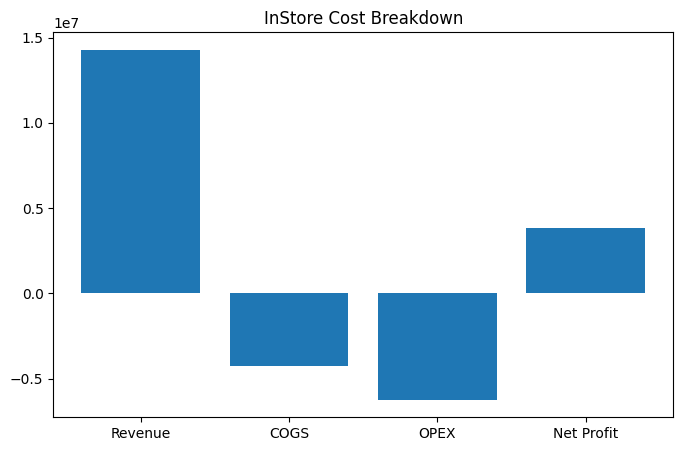

In [63]:
instore_values = [
    df['InStoreRevenue'].sum(),
    -df['InStore_COGS'].sum(),
    -df['InStore_OPEX'].sum(),
    df['InStoreNetProfit'].sum()
]

instore_labels = [
    'Revenue',
    'COGS',
    'OPEX',
    'Net Profit'
]

plt.figure(figsize=(8,5))

plt.bar(instore_labels, instore_values)

plt.title('InStore Cost Breakdown')

plt.show()

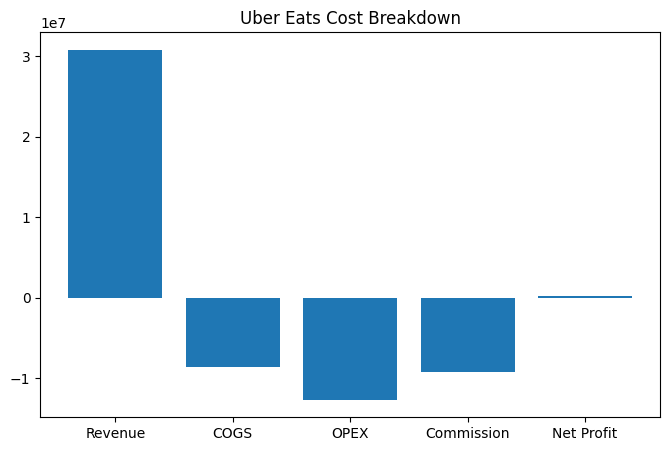

In [64]:
ue_values = [
    df['UberEatsRevenue'].sum(),
    -df['UE_COGS'].sum(),
    -df['UE_OPEX'].sum(),
    -df['UE_Commission'].sum(),
    df['UberEatsNetProfit'].sum()
]

ue_labels = [
    'Revenue',
    'COGS',
    'OPEX',
    'Commission',
    'Net Profit'
]

plt.figure(figsize=(8,5))

plt.bar(ue_labels, ue_values)

plt.title('Uber Eats Cost Breakdown')

plt.show()

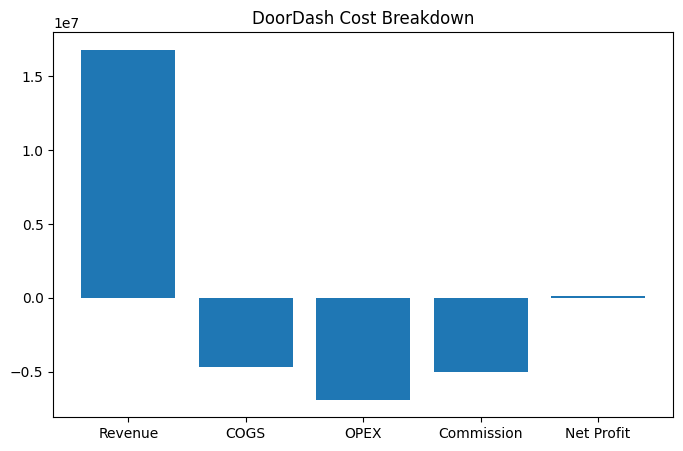

In [65]:
dd_values = [
    df['DoorDashRevenue'].sum(),
    -df['DD_COGS'].sum(),
    -df['DD_OPEX'].sum(),
    -df['DD_Commission'].sum(),
    df['DoorDashNetProfit'].sum()
]

dd_labels = [
    'Revenue',
    'COGS',
    'OPEX',
    'Commission',
    'Net Profit'
]

plt.figure(figsize=(8,5))

plt.bar(dd_labels, dd_values)

plt.title('DoorDash Cost Breakdown')

plt.show()

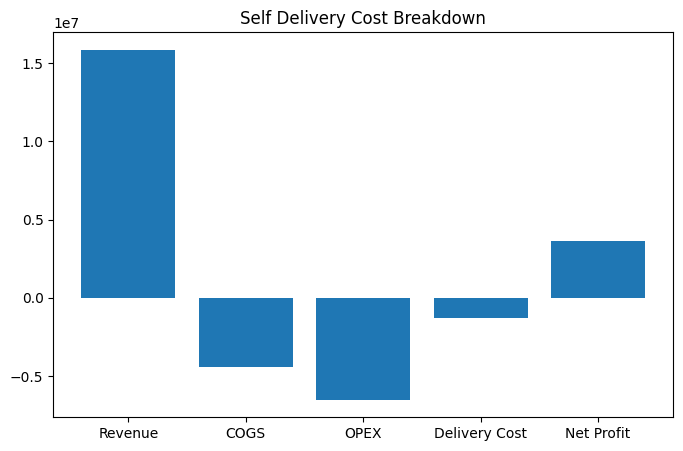

In [66]:
sd_values = [
    df['SelfDeliveryRevenue'].sum(),
    -df['SD_COGS'].sum(),
    -df['SD_OPEX'].sum(),
    -df['SD_Delivery_Cost'].sum(),
    df['SelfDeliveryNetProfit'].sum()
]

sd_labels = [
    'Revenue',
    'COGS',
    'OPEX',
    'Delivery Cost',
    'Net Profit'
]

plt.figure(figsize=(8,5))

plt.bar(sd_labels, sd_values)

plt.title('Self Delivery Cost Breakdown')

plt.show()

In [67]:
commission_rates = [0.10, 0.15, 0.20, 0.25, 0.30, 0.35]

ue_sensitivity = []

for rate in commission_rates:

    simulated_profit = (
        df['UberEatsRevenue']
        - (df['COGSRate'] * df['UberEatsRevenue'])
        - (df['OPEXRate'] * df['UberEatsRevenue'])
        - (rate * df['UberEatsRevenue'])
    ).sum()

    ue_sensitivity.append(simulated_profit)

print(ue_sensitivity)

[np.float64(6430832.195999522), np.float64(4890013.621499523), np.float64(3349195.0469995216), np.float64(1808376.4724995224), np.float64(267557.8979995227), np.float64(-1273260.676500477)]


In [68]:
dd_sensitivity = []

for rate in commission_rates:

    simulated_profit = (
        df['DoorDashRevenue']
        - (df['COGSRate'] * df['DoorDashRevenue'])
        - (df['OPEXRate'] * df['DoorDashRevenue'])
        - (rate * df['DoorDashRevenue'])
    ).sum()

    dd_sensitivity.append(simulated_profit)

print(dd_sensitivity)

[np.float64(3513124.7908294816), np.float64(2673655.743329482), np.float64(1834186.6958294818), np.float64(994717.6483294821), np.float64(155248.6008294822), np.float64(-684220.4466705176)]


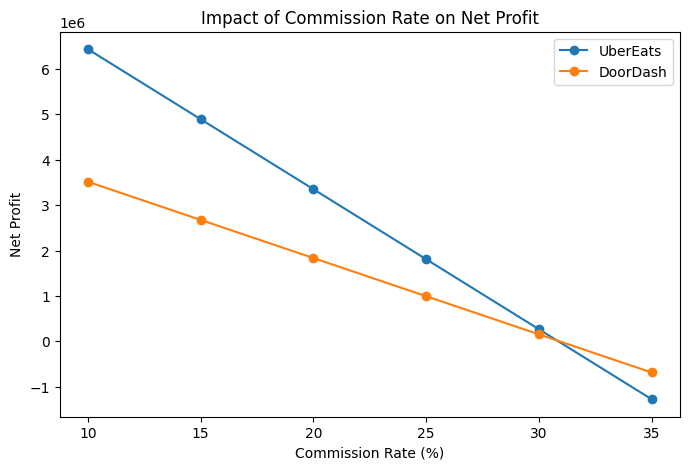

In [69]:
commission_percent = [10,15,20,25,30,35]

plt.figure(figsize=(8,5))

plt.plot(commission_percent, ue_sensitivity, marker='o', label='UberEats')
plt.plot(commission_percent, dd_sensitivity, marker='o', label='DoorDash')

plt.xlabel('Commission Rate (%)')
plt.ylabel('Net Profit')

plt.title('Impact of Commission Rate on Net Profit')

plt.legend()

plt.show()

In [70]:
delivery_multipliers = [1.0, 1.2, 1.4, 1.6, 1.8, 2.0]

sd_sensitivity = []

for multiplier in delivery_multipliers:

    simulated_profit = (
        df['SelfDeliveryRevenue']
        - (df['COGSRate'] * df['SelfDeliveryRevenue'])
        - (df['OPEXRate'] * df['SelfDeliveryRevenue'])
        - (df['SD_DeliveryTotalCost'] * multiplier)
    ).sum()

    sd_sensitivity.append(simulated_profit)

print(sd_sensitivity)

[np.float64(3628278.5008332315), np.float64(3371916.606833231), np.float64(3115554.7128332313), np.float64(2859192.818833231), np.float64(2602830.924833231), np.float64(2346469.0308332313)]


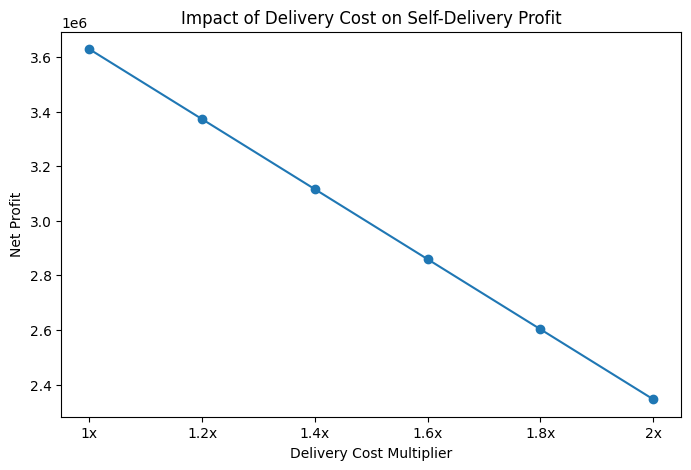

In [71]:
multiplier_labels = ['1x','1.2x','1.4x','1.6x','1.8x','2x']

plt.figure(figsize=(8,5))

plt.plot(multiplier_labels, sd_sensitivity, marker='o')

plt.xlabel('Delivery Cost Multiplier')
plt.ylabel('Net Profit')

plt.title('Impact of Delivery Cost on Self-Delivery Profit')

plt.show()

In [73]:
ue_commission_per_order = (
    df['UE_Commission'].sum()
    / df['UberEatsOrders'].sum()
)

dd_commission_per_order = (
    df['DD_Commission'].sum()
    / df['DoorDashOrders'].sum()
)

print("UE Commission Per Order:", ue_commission_per_order)
print("DD Commission Per Order:", dd_commission_per_order)

UE Commission Per Order: 11.562374664304373
DD Commission Per Order: 11.558211946530319


In [75]:
sd_cost_per_order = (
    df['SD_DeliveryTotalCost'].sum()
    / df['SelfDeliveryOrders'].sum()
)

print("Self Delivery Cost Per Order:", sd_cost_per_order)

Self Delivery Cost Per Order: 3.116824038613512


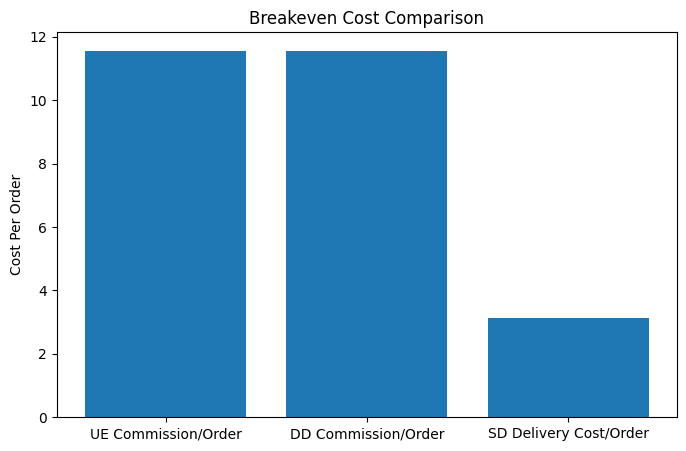

In [76]:
cost_types = [
    'UE Commission/Order',
    'DD Commission/Order',
    'SD Delivery Cost/Order'
]

cost_values = [
    ue_commission_per_order,
    dd_commission_per_order,
    sd_cost_per_order
]

plt.figure(figsize=(8,5))

plt.bar(cost_types, cost_values)

plt.ylabel('Cost Per Order')

plt.title('Breakeven Cost Comparison')

plt.show()

In [77]:
cuisine_instore = df.groupby('CuisineType')[
    'InStore_Margin_Percent'
].mean()

print(cuisine_instore)

CuisineType
Burgers                 31.018341
Chicken Dishes          28.846708
Chinese                 31.016639
Indian                  31.413214
Japanese                31.829411
Kebabs/Mediterranean    29.735974
Pizza                   30.388273
Thai                    31.939056
Name: InStore_Margin_Percent, dtype: float64


In [78]:
cuisine_ue = df.groupby('CuisineType')[
    'UE_Margin_Percent'
].mean()

print(cuisine_ue)

CuisineType
Burgers                 1.037008
Chicken Dishes         -1.355994
Chinese                 0.952414
Indian                  1.507444
Japanese                1.929406
Kebabs/Mediterranean   -0.293965
Pizza                   0.269551
Thai                    1.755716
Name: UE_Margin_Percent, dtype: float64


In [79]:
cuisine_dd = df.groupby('CuisineType')[
    'DD_Margin_Percent'
].mean()

print(cuisine_dd)

CuisineType
Burgers                 1.037009
Chicken Dishes         -1.355986
Chinese                 0.952415
Indian                  1.507442
Japanese                1.929403
Kebabs/Mediterranean   -0.293960
Pizza                   0.269556
Thai                    1.755722
Name: DD_Margin_Percent, dtype: float64


In [80]:
cuisine_sd = df.groupby('CuisineType')[
    'SD_Margin_Percent'
].mean()

print(cuisine_sd)

CuisineType
Burgers                 22.758314
Chicken Dishes          20.350437
Chinese                 22.991084
Indian                  23.317125
Japanese                24.393942
Kebabs/Mediterranean    21.018459
Pizza                   22.153825
Thai                    23.384525
Name: SD_Margin_Percent, dtype: float64


In [81]:
cuisine_margin = pd.DataFrame({

    'InStore': df.groupby('CuisineType')[
        'InStore_Margin_Percent'
    ].mean(),

    'UberEats': df.groupby('CuisineType')[
        'UE_Margin_Percent'
    ].mean(),

    'DoorDash': df.groupby('CuisineType')[
        'DD_Margin_Percent'
    ].mean(),

    'SelfDelivery': df.groupby('CuisineType')[
        'SD_Margin_Percent'
    ].mean()

})

print(cuisine_margin)

                        InStore  UberEats  DoorDash  SelfDelivery
CuisineType                                                      
Burgers               31.018341  1.037008  1.037009     22.758314
Chicken Dishes        28.846708 -1.355994 -1.355986     20.350437
Chinese               31.016639  0.952414  0.952415     22.991084
Indian                31.413214  1.507444  1.507442     23.317125
Japanese              31.829411  1.929406  1.929403     24.393942
Kebabs/Mediterranean  29.735974 -0.293965 -0.293960     21.018459
Pizza                 30.388273  0.269551  0.269556     22.153825
Thai                  31.939056  1.755716  1.755722     23.384525


In [82]:
segment_margin = pd.DataFrame({

    'InStore': df.groupby('Segment')[
        'InStore_Margin_Percent'
    ].mean(),

    'UberEats': df.groupby('Segment')[
        'UE_Margin_Percent'
    ].mean(),

    'DoorDash': df.groupby('Segment')[
        'DD_Margin_Percent'
    ].mean(),

    'SelfDelivery': df.groupby('Segment')[
        'SD_Margin_Percent'
    ].mean()

})

print(segment_margin)

                 InStore   UberEats   DoorDash  SelfDelivery
Segment                                                     
Cafe           36.122329   6.120344   6.120347     27.958588
Full-service   12.528664 -17.435936 -17.435933      4.175960
Ghost Kitchen  45.284855  15.107195  15.107197     36.808296
QSR            35.876969   5.827243   5.827243     27.799102


In [83]:
print(
    cuisine_margin.sort_values(
        by='SelfDelivery',
        ascending=False
    )
)

                        InStore  UberEats  DoorDash  SelfDelivery
CuisineType                                                      
Japanese              31.829411  1.929406  1.929403     24.393942
Thai                  31.939056  1.755716  1.755722     23.384525
Indian                31.413214  1.507444  1.507442     23.317125
Chinese               31.016639  0.952414  0.952415     22.991084
Burgers               31.018341  1.037008  1.037009     22.758314
Pizza                 30.388273  0.269551  0.269556     22.153825
Kebabs/Mediterranean  29.735974 -0.293965 -0.293960     21.018459
Chicken Dishes        28.846708 -1.355994 -1.355986     20.350437


In [84]:
print(
    cuisine_margin.sort_values(
        by='UberEats'
    )
)

                        InStore  UberEats  DoorDash  SelfDelivery
CuisineType                                                      
Chicken Dishes        28.846708 -1.355994 -1.355986     20.350437
Kebabs/Mediterranean  29.735974 -0.293965 -0.293960     21.018459
Pizza                 30.388273  0.269551  0.269556     22.153825
Chinese               31.016639  0.952414  0.952415     22.991084
Burgers               31.018341  1.037008  1.037009     22.758314
Indian                31.413214  1.507444  1.507442     23.317125
Thai                  31.939056  1.755716  1.755722     23.384525
Japanese              31.829411  1.929406  1.929403     24.393942


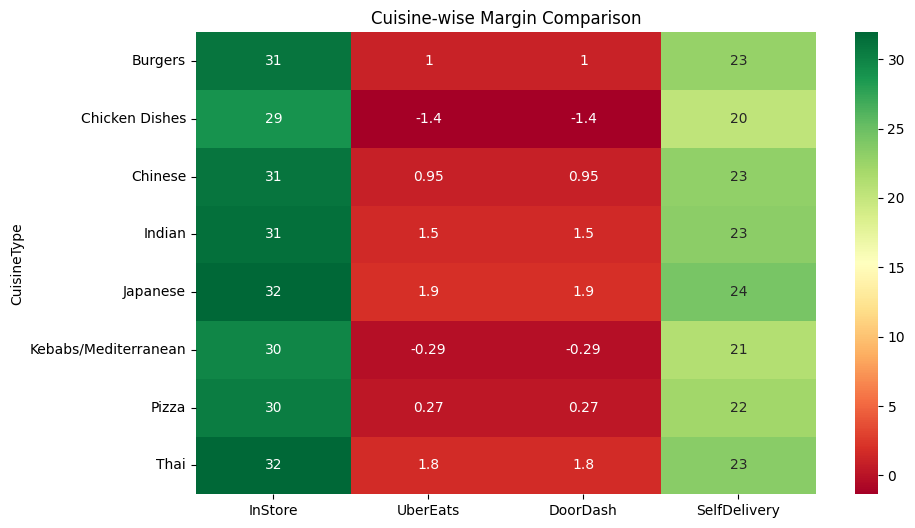

In [85]:
import seaborn as sns

plt.figure(figsize=(10,6))

sns.heatmap(
    cuisine_margin,
    annot=True,
    cmap='RdYlGn'
)

plt.title('Cuisine-wise Margin Comparison')

plt.show()

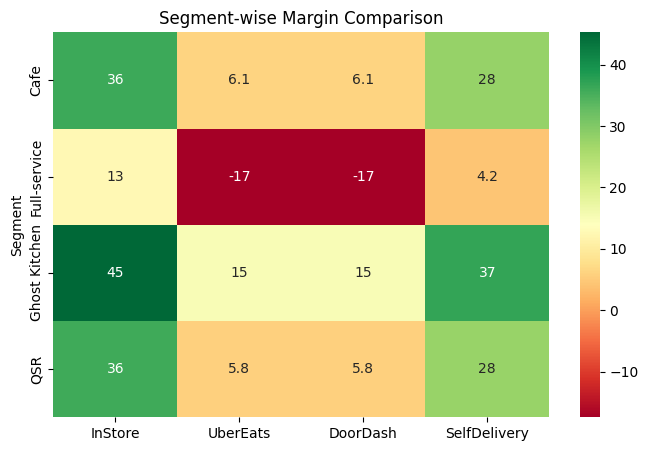

In [86]:
plt.figure(figsize=(8,5))

sns.heatmap(
    segment_margin,
    annot=True,
    cmap='RdYlGn'
)

plt.title('Segment-wise Margin Comparison')

plt.show()

In [87]:
cuisine_profit_order = pd.DataFrame({

    'InStore': df.groupby('CuisineType')[
        'InStore_Profit_Per_Order'
    ].mean(),

    'UberEats': df.groupby('CuisineType')[
        'UE_Profit_Per_Order'
    ].mean(),

    'DoorDash': df.groupby('CuisineType')[
        'DD_Profit_Per_Order'
    ].mean(),

    'SelfDelivery': df.groupby('CuisineType')[
        'SD_Profit_Per_Order'
    ].mean()

})

print(cuisine_profit_order)

                        InStore  UberEats  DoorDash  SelfDelivery
CuisineType                                                      
Burgers               12.007664  0.420908  0.420909      8.852836
Chicken Dishes        11.157469 -0.553813 -0.553811      7.927944
Chinese               11.953293  0.396296  0.396296      8.911593
Indian                12.136689  0.620282  0.620281      9.064867
Japanese              12.405752  0.836559  0.836558      9.558668
Kebabs/Mediterranean  11.367742 -0.075500 -0.075498      8.109659
Pizza                 11.751364  0.148858  0.148859      8.621091
Thai                  12.267043  0.752174  0.752177      9.063624


In [88]:
margin_volatility = {

    'InStore':
    df['InStore_Margin_Percent'].std(),

    'UberEats':
    df['UE_Margin_Percent'].std(),

    'DoorDash':
    df['DD_Margin_Percent'].std(),

    'SelfDelivery':
    df['SD_Margin_Percent'].std()
}

print(margin_volatility)

{'InStore': np.float64(11.988103616059625), 'UberEats': np.float64(12.068526556416064), 'DoorDash': np.float64(12.06852564739573), 'SelfDelivery': np.float64(12.593157291551956)}


In [90]:
cv_analysis = {

    'InStore':
    df['InStore_Margin_Percent'].std()
    / df['InStore_Margin_Percent'].mean(),

    'UberEats':
    df['UE_Margin_Percent'].std()
    / df['UE_Margin_Percent'].mean(),

    'DoorDash':
    df['DD_Margin_Percent'].std()
    / df['DD_Margin_Percent'].mean(),

    'SelfDelivery':
    df['SD_Margin_Percent'].std()
    / df['SD_Margin_Percent'].mean()
}

print(cv_analysis)

{'InStore': np.float64(0.38897007149564583), 'UberEats': np.float64(15.230232425604353), 'DoorDash': np.float64(15.230195561007834), 'SelfDelivery': np.float64(0.5572890041521357)}


In [91]:
ue_losses = df[
    df['UE_Margin_Percent'] < 0
]

print(
    ue_losses[
        [
            'RestaurantName',
            'CuisineType',
            'Segment',
            'UE_Margin_Percent'
        ]
    ]
)

              RestaurantName CuisineType       Segment  UE_Margin_Percent
3     Classic Burgers Tavern     Burgers           QSR          -0.510630
16    Classic Burgers Tavern     Burgers  Full-service         -19.004783
17      Classic Burgers Cafe     Burgers  Full-service         -11.881326
25       Urban Burgers Grill     Burgers          Cafe          -0.763531
26    Classic Burgers Tavern     Burgers  Full-service         -11.300154
...                      ...         ...           ...                ...
1680             Lotus House        Thai  Full-service         -23.466138
1681           Golden Corner        Thai  Full-service         -16.741446
1683            Sakura House        Thai  Full-service         -18.950008
1690          Sakura Kitchen        Thai  Full-service         -20.070592
1695             Lotus Grill        Thai  Full-service         -16.651385

[538 rows x 4 columns]


In [92]:
dd_losses = df[
    df['DD_Margin_Percent'] < 0
]

print(
    dd_losses[
        [
            'RestaurantName',
            'CuisineType',
            'Segment',
            'DD_Margin_Percent'
        ]
    ]
)

              RestaurantName CuisineType       Segment  DD_Margin_Percent
3     Classic Burgers Tavern     Burgers           QSR          -0.510621
16    Classic Burgers Tavern     Burgers  Full-service         -19.004856
17      Classic Burgers Cafe     Burgers  Full-service         -11.881329
25       Urban Burgers Grill     Burgers          Cafe          -0.763531
26    Classic Burgers Tavern     Burgers  Full-service         -11.300211
...                      ...         ...           ...                ...
1680             Lotus House        Thai  Full-service         -23.466176
1681           Golden Corner        Thai  Full-service         -16.741448
1683            Sakura House        Thai  Full-service         -18.949952
1690          Sakura Kitchen        Thai  Full-service         -20.070555
1695             Lotus Grill        Thai  Full-service         -16.651354

[538 rows x 4 columns]


In [93]:
sd_losses = df[
    df['SD_Margin_Percent'] < 0
]

print(
    sd_losses[
        [
            'RestaurantName',
            'CuisineType',
            'Segment',
            'SD_Margin_Percent'
        ]
    ]
)

              RestaurantName CuisineType       Segment  SD_Margin_Percent
48       King Burgers Tavern     Burgers  Full-service          -5.981020
77    Classic Burgers Corner     Burgers  Full-service          -6.133784
101        Top Burgers Grill     Burgers  Full-service          -4.412595
118         Top Burgers Cafe     Burgers  Full-service          -0.638923
128      Urban Burgers Grill     Burgers  Full-service          -0.550716
...                      ...         ...           ...                ...
1643             Sakura Cafe        Thai  Full-service          -3.967333
1665           Sakura Bistro        Thai  Full-service          -1.861573
1666             Lotus Diner        Thai  Full-service          -2.805672
1680             Lotus House        Thai  Full-service          -2.038686
1695             Lotus Grill        Thai  Full-service          -1.715370

[90 rows x 4 columns]


In [94]:
loss_counts = {

    'UberEats':
    len(
        df[
            df['UE_Margin_Percent'] < 0
        ]
    ),

    'DoorDash':
    len(
        df[
            df['DD_Margin_Percent'] < 0
        ]
    ),

    'SelfDelivery':
    len(
        df[
            df['SD_Margin_Percent'] < 0
        ]
    ),

    'InStore':
    len(
        df[
            df['InStore_Margin_Percent'] < 0
        ]
    )
}

print(loss_counts)

{'UberEats': 538, 'DoorDash': 538, 'SelfDelivery': 90, 'InStore': 0}


In [95]:
high_risk = df[

    (df['UE_Margin_Percent'] < 0)
    |
    (df['DD_Margin_Percent'] < 0)

]

print(
    high_risk[
        [
            'RestaurantName',
            'CuisineType',
            'Segment',
            'UE_Margin_Percent',
            'DD_Margin_Percent',
            'SD_Margin_Percent'
        ]
    ]
)

              RestaurantName CuisineType       Segment  UE_Margin_Percent  \
3     Classic Burgers Tavern     Burgers           QSR          -0.510630   
16    Classic Burgers Tavern     Burgers  Full-service         -19.004783   
17      Classic Burgers Cafe     Burgers  Full-service         -11.881326   
25       Urban Burgers Grill     Burgers          Cafe          -0.763531   
26    Classic Burgers Tavern     Burgers  Full-service         -11.300154   
...                      ...         ...           ...                ...   
1680             Lotus House        Thai  Full-service         -23.466138   
1681           Golden Corner        Thai  Full-service         -16.741446   
1683            Sakura House        Thai  Full-service         -18.950008   
1690          Sakura Kitchen        Thai  Full-service         -20.070592   
1695             Lotus Grill        Thai  Full-service         -16.651385   

      DD_Margin_Percent  SD_Margin_Percent  
3             -0.510621       

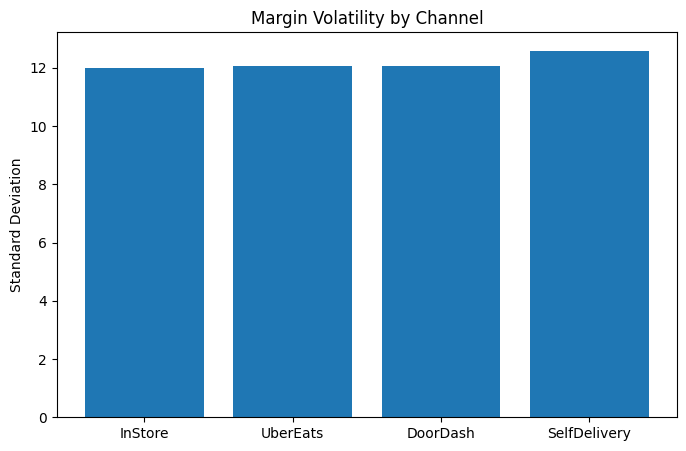

In [96]:
channels = list(margin_volatility.keys())
volatility = list(margin_volatility.values())

plt.figure(figsize=(8,5))

plt.bar(channels, volatility)

plt.ylabel('Standard Deviation')

plt.title('Margin Volatility by Channel')

plt.show()

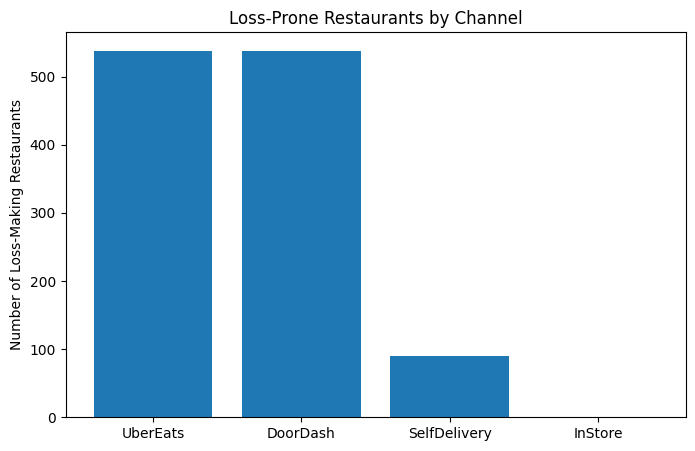

In [97]:
loss_channels = list(loss_counts.keys())
loss_values = list(loss_counts.values())

plt.figure(figsize=(8,5))

plt.bar(loss_channels, loss_values)

plt.ylabel('Number of Loss-Making Restaurants')

plt.title('Loss-Prone Restaurants by Channel')

plt.show()

In [98]:
risk_score = pd.DataFrame({

    'AverageMargin': [
        df['InStore_Margin_Percent'].mean(),
        df['UE_Margin_Percent'].mean(),
        df['DD_Margin_Percent'].mean(),
        df['SD_Margin_Percent'].mean()
    ],

    'Volatility': [
        df['InStore_Margin_Percent'].std(),
        df['UE_Margin_Percent'].std(),
        df['DD_Margin_Percent'].std(),
        df['SD_Margin_Percent'].std()
    ]

},

index=[
    'InStore',
    'UberEats',
    'DoorDash',
    'SelfDelivery'
])

risk_score['RiskIndex'] = (
    risk_score['Volatility']
    / risk_score['AverageMargin']
)

print(risk_score)

              AverageMargin  Volatility  RiskIndex
InStore           30.820118   11.988104   0.388970
UberEats           0.792406   12.068527  15.230232
DoorDash           0.792408   12.068526  15.230196
SelfDelivery      22.597175   12.593157   0.557289
